The absolute SHAP values were used to predict. This was done because the aim of this analysis was to identify which nucleotide positions
contributed most strongly to the model predictions, independent of whether their effects
were positive or negative

Feature matrix shape: (19469, 247)
Feature models selected: ['Feat4-GB', 'Feat4-RF', 'Feat13-GB', 'Feat13-RF']
Processing Feat4-GB ...
Processing Feat4-RF ...
Processing Feat13-GB ...
Processing Feat13-RF ...


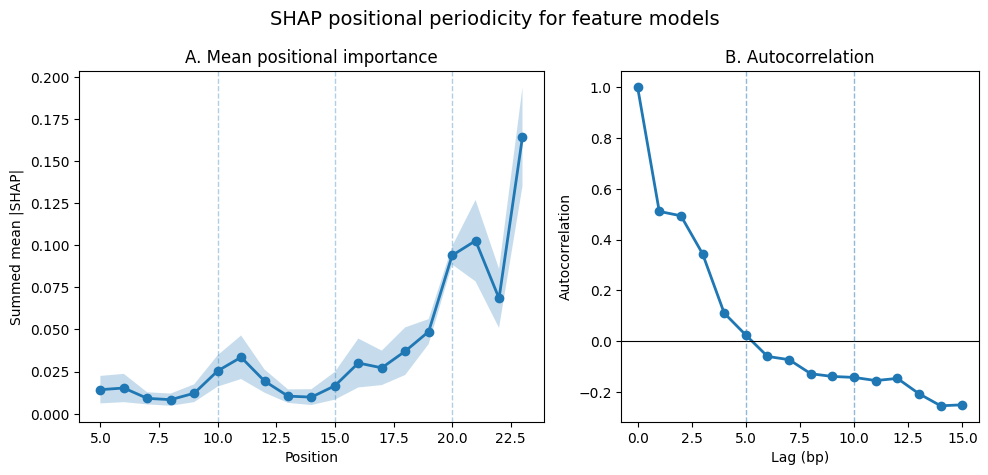

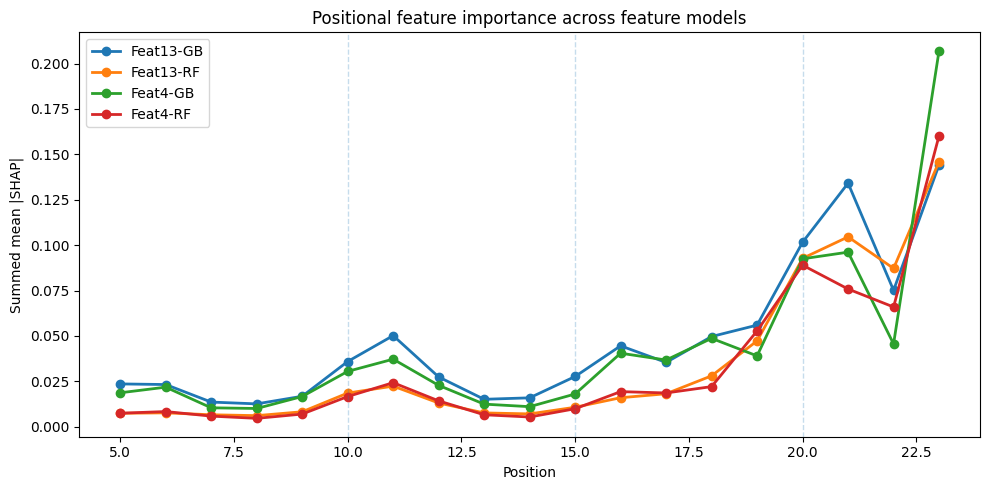

Done.


In [2]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# =========================================================
# 1. FILES / MODELS
# =========================================================

MODELS = [
    {"name": "Feat4-GB",  "path": "shape_booster4_model.joblib", "type": "feat"},
    {"name": "Feat4-RF",  "path": "shape_rf_model_4.joblib",     "type": "feat"},
    {"name": "Feat13-GB", "path": "shape_booster13model.joblib", "type": "feat"},
    {"name": "Feat13-RF", "path": "shape_rf_model13.joblib",     "type": "feat"},
]

X_test_feat_path = "X_feature.joblib"
outdir = "Importance_Picture"
n_sample = 10000


# =========================================================
# 2. HELPERS
# =========================================================

def parse_feature_name(feature_name):
    """
    Parses names like Roll_23 -> ('Roll', 23)
    Returns (None, None) if no positional pattern is found.
    """
    m = re.match(r"^([A-Za-z]+)_(\d+)$", str(feature_name))
    if m is None:
        return None, None
    return m.group(1), int(m.group(2))


def get_shap_matrix(model, X):
    """
    Return SHAP values as 2D array.
    """
    explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")
    shap_values = explainer.shap_values(X, approximate=True)

    if isinstance(shap_values, list):
        shap_vals = shap_values[1] if len(shap_values) > 1 else shap_values[0]
    else:
        shap_vals = shap_values

    shap_vals = np.asarray(shap_vals)

    if shap_vals.ndim == 3:
        shap_vals = shap_vals[:, :, 0]

    return shap_vals


def align_input_to_model(model, X_test, feature_columns_from_bundle=None):
    """
    Align X_test to the columns expected by the model.
    """
    if feature_columns_from_bundle is not None:
        required_cols = list(feature_columns_from_bundle)
    elif hasattr(model, "feature_names_in_"):
        required_cols = list(model.feature_names_in_)
    else:
        raise ValueError("No feature columns available in bundle or model.")

    if not isinstance(X_test, pd.DataFrame):
        raise ValueError("X_test must be a pandas DataFrame with column names.")

    missing = [c for c in required_cols if c not in X_test.columns]
    if missing:
        raise ValueError(f"Missing columns for model: {missing[:15]}")

    return X_test[required_cols].copy()


def autocorrelation(x, max_lag=None):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)

    if max_lag is None:
        max_lag = len(x) - 1

    denom = np.sum(x ** 2)
    if denom == 0:
        return np.arange(max_lag + 1), np.zeros(max_lag + 1)

    acf = [1.0]
    for lag in range(1, max_lag + 1):
        num = np.sum(x[:-lag] * x[lag:])
        acf.append(num / denom)

    return np.arange(max_lag + 1), np.array(acf)


def ensure_dataframe(X, name):
    if isinstance(X, pd.DataFrame):
        return X
    raise ValueError(f"{name} must be a pandas DataFrame with named columns.")


# =========================================================
# 3. MAIN ANALYSIS
# =========================================================

def evaluate_feature_models(model_configs, X_test_feat, outdir="Importance_Picture", n_sample=1000):
    os.makedirs(outdir, exist_ok=True)

    all_feature_importance = []
    failed_models = []

    for cfg in model_configs:
        name = cfg["name"]
        path = cfg["path"]

        print(f"Processing {name} ...")

        bundle = joblib.load(path)

        if not isinstance(bundle, dict):
            raise ValueError(f"{path} is not a bundle dictionary.")

        if "model" not in bundle:
            raise KeyError(f"{path} does not contain 'model'.")

        model = bundle["model"]
        feature_columns = bundle.get("feature_columns", None)

        try:
            X_current = align_input_to_model(
                model,
                X_test_feat,
                feature_columns_from_bundle=feature_columns
            )
        except Exception as e:
            print(f"Skipping {name}: {e}")
            failed_models.append({"model": name, "reason": str(e)})
            continue

        n_use = min(len(X_current), n_sample)
        X_sub = X_current.sample(n_use, random_state=42)

        shap_vals = get_shap_matrix(model, X_sub)
        mean_abs = np.abs(shap_vals).mean(axis=0)

        rows = []
        for feat, val in zip(X_sub.columns, mean_abs):
            feature_type, position = parse_feature_name(feat)
            rows.append({
                "model": name,
                "feature": feat,
                "feature_type": feature_type,
                "position": position,
                "mean_abs_shap": val
            })

        df_model = pd.DataFrame(rows)
        all_feature_importance.append(df_model)

    if len(all_feature_importance) == 0:
        raise ValueError("No models could be evaluated successfully.")

    all_feature_importance = pd.concat(all_feature_importance, ignore_index=True)
    all_feature_importance.to_csv(
        os.path.join(outdir, "feature_level_shap_importance.csv"),
        index=False
    )

    if len(failed_models) > 0:
        pd.DataFrame(failed_models).to_csv(
            os.path.join(outdir, "failed_models.csv"),
            index=False
        )

    positional_df = all_feature_importance.dropna(subset=["position"]).copy()

    if len(positional_df) == 0:
        print("No positional features like Roll_23 were found.")
        return all_feature_importance, None, None

    positional_df["position"] = positional_df["position"].astype(int)
    positional_df.to_csv(
        os.path.join(outdir, "feature_level_shap_importance_positional.csv"),
        index=False
    )

    pos_df = (
        positional_df
        .groupby(["model", "position"], as_index=False)["mean_abs_shap"]
        .sum()
        .rename(columns={"mean_abs_shap": "positional_importance"})
    )
    pos_df.to_csv(
        os.path.join(outdir, "position_level_shap_importance.csv"),
        index=False
    )

    pos_type_df = (
        positional_df
        .groupby(["model", "feature_type", "position"], as_index=False)["mean_abs_shap"]
        .sum()
    )
    pos_type_df.to_csv(
        os.path.join(outdir, "position_featuretype_shap_importance.csv"),
        index=False
    )

    # =====================================================
    # PLOT 1: Mean positional importance + autocorrelation
    # =====================================================

    pivot = pos_df.pivot(index="model", columns="position", values="positional_importance")
    pivot = pivot.sort_index(axis=1)

    positions = pivot.columns.to_numpy()
    mean_imp = pivot.mean(axis=0).to_numpy()
    std_imp = pivot.std(axis=0).to_numpy()

    max_lag = min(15, len(mean_imp) - 1)
    lags, acf_vals = autocorrelation(mean_imp, max_lag=max_lag)

    fig = plt.figure(figsize=(10, 4.8))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.3, 1.0])

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(positions, mean_imp, marker="o", linewidth=2)
    ax1.fill_between(positions, mean_imp - std_imp, mean_imp + std_imp, alpha=0.25)
    ax1.set_xlabel("Position")
    ax1.set_ylabel("Summed mean |SHAP|")
    ax1.set_title("A. Mean positional importance")

    p0 = positions.min()
    for p in positions:
        rel = p - p0
        if rel > 0 and rel % 5 == 0:
            ax1.axvline(p, linestyle="--", linewidth=1, alpha=0.35)

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(lags, acf_vals, marker="o", linewidth=2)
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.axvline(5, linestyle="--", linewidth=1, alpha=0.5)
    ax2.axvline(10, linestyle="--", linewidth=1, alpha=0.5)
    ax2.set_xlabel("Lag (bp)")
    ax2.set_ylabel("Autocorrelation")
    ax2.set_title("B. Autocorrelation")

    fig.suptitle("SHAP positional periodicity for feature models", fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, "SHAP_periodicity_feature_models.png"),
                dpi=600, bbox_inches="tight")
    plt.savefig(os.path.join(outdir, "SHAP_periodicity_feature_models.pdf"),
                bbox_inches="tight")
    plt.show()
    plt.close()

    # =====================================================
    # PLOT 2: One line per model across positions
    # =====================================================

    fig, ax = plt.subplots(figsize=(10, 5))

    for model_name in pivot.index:
        ax.plot(
            positions,
            pivot.loc[model_name].values,
            marker="o",
            linewidth=2,
            label=model_name
        )

    for p in positions:
        rel = p - p0
        if rel > 0 and rel % 5 == 0:
            ax.axvline(p, linestyle="--", linewidth=1, alpha=0.25)

    ax.set_xlabel("Position")
    ax.set_ylabel("Summed mean |SHAP|")
    ax.set_title("Positional feature importance across feature models")
    ax.legend()
    plt.tight_layout()

    plt.savefig(os.path.join(outdir, "SHAP_positional_importance_feature_models.pdf"),
                dpi=600, bbox_inches="tight")
    plt.savefig(os.path.join(outdir, "SHAP_positional_importance_feature_models.pdf"),
                bbox_inches="tight")
    plt.show()
    plt.close()

    return all_feature_importance, pos_df, pos_type_df


# =========================================================
# 4. RUN
# =========================================================

X_test_feat = joblib.load(X_test_feat_path)
X_test_feat = ensure_dataframe(X_test_feat, "X_test_feat")

print("Feature matrix shape:", X_test_feat.shape)

model_configs_feat = [m for m in MODELS if m["type"] == "feat"]
print("Feature models selected:", [m["name"] for m in model_configs_feat])

all_feature_importance, pos_df, pos_type_df = evaluate_feature_models(
    model_configs=model_configs_feat,
    X_test_feat=X_test_feat,
    outdir=outdir,
    n_sample=n_sample
)

print("Done.")

In [3]:
bundle = joblib.load("shape_booster4_model.joblib")
print(type(bundle))

if isinstance(bundle, dict):
    print(bundle.keys())
else:
    print("This file is not a dict bundle")

<class 'dict'>
dict_keys(['version', 'trained_at', 'label_col', 'families', 'keep_window', 'exclude', 'rf_params', 'seed', 'feature_columns', 'imputer', 'calibrator', 'model', 'y_true_te', 'y_pred_te'])
